In [1]:
%%capture
%pip install torch transformers
%pip install -U "huggingface_hub[cli]"
%pip install accelerate

# (recommended inside a fresh venv/conda env)
%pip uninstall -y huggingface_hub
%pip install "huggingface-hub>=0.34.0,<1.0"
# sanity check
%python -c "import transformers, huggingface_hub as h; print('transformers', transformers.__version__, 'hub', h.__version__)"

In [2]:
import os
os.environ["HF_HOME"] = "./hf"
os.environ["HF_HUB_CACHE"] = "./hf/hub"
os.environ['PATH'] += ':/storage/home/hcoda1/9/kzhang430/.local/bin'
os.environ.setdefault("HF_HOME", "./hf")
os.environ.setdefault("HF_HUB_CACHE", "./hf/hub")
os.environ.setdefault("HF_DATASETS_CACHE", "./hf/datasets")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import re
import json
from huggingface_hub import login

In [3]:
!hf auth whoami

user:  wristycargo


# Arithmetic Experiments 2: Single-Digit Addition Statistics

**Goal**: Measure model surprisal and exact-match accuracy for single-digit equations of the form `a + b = c`.

**Plan**:
1. Evaluate all 100 single-digit addition problems on Pythia
2. Summarize accuracy and surprisal overall and by carry status
3. Visualize the full `a × b` grid
4. Identify the lowest and highest scoring addition problems

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
import itertools
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment Configuration — edit here
# ─────────────────────────────────────────────────────────────────────────────
import random

MODEL_NAME = "EleutherAI/pythia-12b-deduped"   # Pythia model to evaluate

K_SHOT     = 4    # k-shot demonstrations prepended to every prompt (0 = zero-shot)
KSHOT_SEED = 42    # random seed for demo selection (ensures reproducibility)

BATCH_SIZE_LOGPROB  = 64   # batch size for surprisal eval (lower if OOM)
BATCH_SIZE_ACCURACY = 32   # batch size for greedy-decode eval

## Utilities: Model Loading

In [6]:
PYTHIA_MODELS = [
    "EleutherAI/pythia-70m-deduped",
    "EleutherAI/pythia-160m-deduped",
    "EleutherAI/pythia-410m-deduped",
    "EleutherAI/pythia-1b-deduped",
    "EleutherAI/pythia-1.4b-deduped",
]

def load_model(name, device=device):
    print(f"Loading {name}...")
    tok = AutoTokenizer.from_pretrained(name)
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id
    mdl = AutoModelForCausalLM.from_pretrained(
        name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    mdl.eval()
    n = sum(p.numel() for p in mdl.parameters()) / 1e6
    print(f"  Loaded: {n:.0f}M params on {next(mdl.parameters()).device}")
    return tok, mdl

## Utilities: Evaluation Functions

In [7]:
@torch.inference_mode()
def eval_logprob(model, tokenizer, df, batch_size=32, prompt_col="prompt", target_col="target"):
    """Compute per-example log-probabilities of the target given the prompt."""
    prompts = df[prompt_col].tolist()
    targets = df[target_col].astype(str).tolist()
    full_texts = [f"{p} {t}" for p, t in zip(prompts, targets)]
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    out_rows = []
    for i in tqdm(range(0, len(prompts), batch_size), desc="logprob", leave=False):
        bp = prompts[i:i+batch_size]
        bf = full_texts[i:i+batch_size]
        prompt_enc = tokenizer(bp, add_special_tokens=False)
        full_enc = tokenizer(bf, add_special_tokens=False)

        batch_ids, batch_mask, prompt_lens, target_lens = [], [], [], []
        for p_ids, full_ids in zip(prompt_enc["input_ids"], full_enc["input_ids"]):
            if full_ids[:len(p_ids)] != p_ids:
                raise ValueError("Prompt tokens are not a prefix of the full prompt+target tokens.")
            t_len = len(full_ids) - len(p_ids)
            if t_len <= 0:
                raise ValueError("Target tokenization produced an empty suffix.")
            batch_ids.append(full_ids)
            batch_mask.append([1]*len(full_ids))
            prompt_lens.append(len(p_ids))
            target_lens.append(t_len)

        max_len = max(len(x) for x in batch_ids)
        padded_ids  = [ids  + [pad_id]*(max_len-len(ids))  for ids  in batch_ids]
        padded_mask = [mask + [0]*(max_len-len(mask)) for mask in batch_mask]

        input_ids      = torch.tensor(padded_ids,  device=model.device)
        attention_mask = torch.tensor(padded_mask, device=model.device)
        logits   = model(input_ids=input_ids, attention_mask=attention_mask).logits
        log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)
        next_tok  = input_ids[:, 1:]
        token_lp  = log_probs.gather(2, next_tok.unsqueeze(-1)).squeeze(-1)

        for p_len, t_len, tlp in zip(prompt_lens, target_lens, token_lp):
            start = p_len - 1
            tgt_lp = tlp[start:start+t_len]
            out_rows.append({
                "target_logprob":     tgt_lp.sum().item(),
                "avg_target_logprob": tgt_lp.mean().item(),
            })

    result = df.copy()
    result["target_logprob"]     = [r["target_logprob"]     for r in out_rows]
    result["avg_target_logprob"] = [r["avg_target_logprob"] for r in out_rows]
    result["surprisal"]          = -result["avg_target_logprob"]
    return result

In [8]:
@torch.inference_mode()
def eval_accuracy(model, tokenizer, df, batch_size=16, prompt_col="prompt",
                  target_col="target", max_new_tokens=6):
    """Greedy decoding + exact-match accuracy."""
    prompts = df[prompt_col].tolist()
    targets = df[target_col].astype(str).tolist()
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    preds = []
    for i in tqdm(range(0, len(prompts), batch_size), desc="accuracy", leave=False):
        bp  = prompts[i:i+batch_size]
        enc = tokenizer(bp, return_tensors="pt", padding=True,
                        add_special_tokens=False).to(model.device)
        out = model.generate(
            **enc, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=pad_id
        )
        for inp_ids, out_ids in zip(enc["input_ids"], out):
            gen = tokenizer.decode(out_ids[len(inp_ids):],
                                   skip_special_tokens=True).strip()
            m = re.match(r"(-?\d+)", gen)
            preds.append(m.group(1) if m else gen)

    result = df.copy()
    result["prediction"] = preds
    result["correct"]    = [p.strip() == t.strip() for p, t in zip(preds, targets)]
    return result

### Tokenization Sanity Check

This quick check shows why we score the fully tokenized `prompt + " " + target` string instead of tokenizing the prompt and target separately. For GPT-style tokenizers, the natural continuation after `=` is often a single whitespace-prefixed number token such as `" 0"` or `" 12"`.

In [9]:
# # Token-boundary sanity check for arithmetic prompts
# examples = [
#     "0 + 0 = 0",
#     "0 + 0 = ",
#     "0",
#     " 0",
#     "9 + 9 = 18",
#     "18",
#     " 18",
# ]

# for text in examples:
#     ids = tokenizer.encode(text, add_special_tokens=False)
#     toks = [tokenizer.decode([tok_id]) for tok_id in ids]
#     print(f"{text!r}")
#     print(f"  ids : {ids}")
#     print(f"  toks: {toks}")
#     print()

# print("Observation:")
# print("  Full strings like '0 + 0 = 0' typically end in a single token such as ' 0'.")
# print("  If you tokenize the prompt and target separately, you instead force the model")
# print("  to score a standalone space token followed by '0', which is a different continuation.")

In [10]:
# ─── K-shot Prompting Utilities ──────────────────────────────────────────────
#
# We use a fixed prefix (same k demonstrations for every query) rather than
# per-query dynamic selection. This is the standard approach for logprob/
# surprisal evaluation because it keeps the context identical across queries,
# making surprisal values directly comparable. The only downside is a small
# risk that the query itself appears in the demos; with k <= 16 and 100+
# problems this is unlikely, but `apply_kshot_prefix` optionally excludes
# the exact query row to be safe.
#
# If you prefer per-query selection (e.g. for few-shot accuracy studies),
# replace `build_kshot_prefix` with a function that samples differently per row.

def build_kshot_prefix(k, problem_type="single_addition", seed=KSHOT_SEED):
    """
    Build a fixed k-shot demonstration string.

    Parameters
    ----------
    k            : int  number of demonstrations (0 returns empty string)
    problem_type : str  "single_addition" (a+b=) or "2digit" (A+B=)
    seed         : int  RNG seed for reproducibility

    Returns
    -------
    str  newline-separated demonstration lines.
    """
    if k == 0:
        return ""

    rng = random.Random(seed)

    if problem_type == "single_addition":
        pool = [(a, b) for a, b in itertools.product(range(10), range(10))]
        rng.shuffle(pool)
        lines = [f"{a} + {b} = {a+b}" for a, b in pool[:k]]

    elif problem_type == "2digit":
        pool = [(A, B) for A in range(10, 100) for B in range(10, 100)]
        rng.shuffle(pool)
        lines = [f"{A} + {B} = {A+B}" for A, B in pool[:k]]

    else:
        raise ValueError(f"Unknown problem_type: {problem_type!r}")

    return "\n".join(lines)


def apply_kshot_prefix(df, prefix, prompt_col="prompt", out_col="eval_prompt"):
    """
    Prepend `prefix` to every prompt in df[prompt_col], storing the result in
    df[out_col]. Pass `prompt_col="eval_prompt"` to `eval_logprob` /
    `eval_accuracy`.

    If prefix is empty, `eval_prompt == prompt` (zero-shot pass-through).
    """
    df = df.copy()
    df[out_col] = (prefix + "\n" + df[prompt_col]) if prefix else df[prompt_col]
    return df


# Quick sanity-check
_demo = build_kshot_prefix(K_SHOT, "single_addition")
print(f"K_SHOT = {K_SHOT}")
if _demo:
    print(f"Demo prefix ({K_SHOT} examples):")
    print(_demo)
else:
    print("Zero-shot mode - no prefix added.")

K_SHOT = 4
Demo prefix (4 examples):
4 + 2 = 6
4 + 1 = 5
9 + 1 = 10
0 + 9 = 9


## Utilities: Pretraining Frequency

In [11]:
JSONL_PATH = "./pile_arith_matches_full_fresh_deduped.jsonl"

def load_freq_counts(path=JSONL_PATH):
    """
    Load addition-specific frequency counts from Pile JSONL.
    freq_ab[(a,b)] = # times 'a + b' appeared (all digit lengths).
    freq_digit[d]  = # times digit d appeared as operand in any + expression.
    """
    freq_ab    = Counter()
    freq_digit = Counter()

    with open(path, "r") as f:
        for line in f:
            r = json.loads(line.strip())
            if r.get("op") != "+":
                continue
            a, b = int(r["a"]), int(r["b"])
            freq_ab[(a, b)] += 1
            # Accumulate per-digit frequencies for single-digit operands
            if 0 <= a <= 9:
                freq_digit[a] += 1
            if 0 <= b <= 9:
                freq_digit[b] += 1

    total = sum(freq_ab.values())
    print(f"Loaded {total:,} '+' expressions from Pile")
    print(f"  Unique (a,b) pairs: {len(freq_ab):,}")
    return freq_ab, freq_digit

freq_ab, freq_digit = load_freq_counts()

Loaded 90,286 '+' expressions from Pile
  Unique (a,b) pairs: 14,062


---
# Part 1: Single-Digit Addition

We evaluate all **100 problems** of the form `a + b =` where:
- `a, b ∈ {0,...,9}` are single digits

These 100 problems cover every possible single-digit addition prompt.

We measure both **surprisal** (negative avg log-prob of the correct answer) and **exact-match accuracy** (greedy decoding).

In [12]:
# ── Generate all single-digit addition problems ─────────────────────────────
def gen_single_digit_addition_problems():
    rows = []
    for a, b in itertools.product(range(10), range(10)):
        result = a + b
        prompt = f"{a} + {b} ="
        rows.append({
            "a": a,
            "b": b,
            "c": result,
            "prompt": prompt,
            "target": str(result),
            "has_carry": int(result >= 10),
            "digit_sum": result,
            "freq_a": freq_digit.get(a, 0),
            "freq_b": freq_digit.get(b, 0),
        })
    return pd.DataFrame(rows)


df_single = gen_single_digit_addition_problems()
print(f"Generated {len(df_single)} single-digit addition problems")
print(df_single[["prompt", "target", "has_carry"]].sample(8, random_state=0))

Generated 100 single-digit addition problems
     prompt target  has_carry
26  2 + 6 =      8          0
86  8 + 6 =     14          1
2   0 + 2 =      2          0
55  5 + 5 =     10          1
75  7 + 5 =     12          1
93  9 + 3 =     12          1
16  1 + 6 =      7          0
73  7 + 3 =     10          1


In [13]:
# ── Load model (MODEL_NAME set in Config cell above) ─────────────────────────
tokenizer, model = load_model(MODEL_NAME)

Loading EleutherAI/pythia-12b-deduped...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  Loaded: 11846M params on cuda:0


In [14]:
# ── Evaluate single-digit addition problems ─────────────────────────────────
_prefix_single = build_kshot_prefix(K_SHOT)
df_single_kshot = apply_kshot_prefix(df_single, _prefix_single)

df_single_eval = eval_logprob(
    model,
    tokenizer,
    df_single_kshot,
    batch_size=BATCH_SIZE_LOGPROB,
    prompt_col="eval_prompt",
)
df_single_eval = eval_accuracy(
    model,
    tokenizer,
    df_single_eval,
    batch_size=BATCH_SIZE_ACCURACY,
    prompt_col="eval_prompt",
)
df_single_eval["model"] = MODEL_NAME
df_single_eval["k_shot"] = K_SHOT

print(f"K_SHOT={K_SHOT}  |  Overall accuracy : {df_single_eval['correct'].mean():.3f}")
print(f"K_SHOT={K_SHOT}  |  Mean surprisal   : {df_single_eval['surprisal'].mean():.3f}")
print()
print("By carry status (sum >= 10):")
print(df_single_eval.groupby("has_carry")[["correct", "surprisal"]].mean())

logprob:   0%|          | 0/2 [00:00<?, ?it/s]

accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

K_SHOT=4  |  Overall accuracy : 0.990
K_SHOT=4  |  Mean surprisal   : 0.067

By carry status (sum >= 10):
            correct  surprisal
has_carry                     
0          0.981818   0.086809
1          1.000000   0.043490


In [16]:
# ── Prefix-robustness check: repeat the single-digit eval over several fixed seeds ──
#
# The cell above is the canonical run (seed=KSHOT_SEED) that feeds all downstream
# analysis. Here we re-run the same evaluation under a few *different* fixed prefixes
# to confirm the carry effect isn't an artifact of one particular demo draw.
# Each seed still uses ONE fixed prefix for all queries (required for comparable
# surprisal); we vary only which prefix, then report mean +/- std across seeds.

PREFIX_SEEDS = [KSHOT_SEED, 1, 7, 123, 2024]

_seed_rows = []
for _s in PREFIX_SEEDS:
    _prefix = build_kshot_prefix(K_SHOT, "single_addition", seed=_s)
    _df = apply_kshot_prefix(df_single, _prefix)
    _df = eval_logprob(model, tokenizer, _df,
                       batch_size=BATCH_SIZE_LOGPROB, prompt_col="eval_prompt")
    _df = eval_accuracy(model, tokenizer, _df,
                        batch_size=BATCH_SIZE_ACCURACY, prompt_col="eval_prompt")
    g = _df.groupby("has_carry")[["correct", "surprisal"]].mean()
    g["seed"] = _s
    _seed_rows.append(g.reset_index())

df_seed_sweep = pd.concat(_seed_rows, ignore_index=True)

# Spread across prefixes, per carry status
seed_summary = (df_seed_sweep
                .groupby("has_carry")[["correct", "surprisal"]]
                .agg(["mean", "std"])
                .round(3))
print(f"K_SHOT={K_SHOT}  |  prefix seeds: {PREFIX_SEEDS}")
print("Across-prefix mean +/- std, by carry status:")
print(seed_summary)
print()
# Carry effect (carry - no_carry) per seed, to check the sign is stable
_piv = df_seed_sweep.pivot(index="seed", columns="has_carry", values="surprisal")
_piv["carry_surprisal_gap"] = _piv[1] - _piv[0]
print("Surprisal gap (carry - no_carry) per prefix seed:")
print(_piv["carry_surprisal_gap"].round(3))


logprob:   0%|          | 0/2 [00:00<?, ?it/s]

accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

logprob:   0%|          | 0/2 [00:00<?, ?it/s]

accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

logprob:   0%|          | 0/2 [00:00<?, ?it/s]

...

logprob:   0%|          | 0/2 [00:00<?, ?it/s]

accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

logprob:   0%|          | 0/2 [00:00<?, ?it/s]

accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

K_SHOT=4  |  prefix seeds: [42, 1, 7, 123, 2024]
Across-prefix mean +/- std, by carry status:
          correct        surprisal       
             mean    std      mean    std
has_carry                                
0           0.996  0.008     0.028  0.033
1           0.996  0.010     0.063  0.026

Surprisal gap (carry - no_carry) per prefix seed:
seed
1       0.048
7       0.049
42     -0.043
123     0.093
2024    0.029
Name: carry_surprisal_gap, dtype: float64


### Are there significant differences across addition problems?

In [17]:
from scipy.stats import f_oneway, variation

surp_vals = df_single_eval["surprisal"].values
acc_vals  = df_single_eval["correct"].values.astype(float)

cv = variation(surp_vals)
print(f"Surprisal — min: {surp_vals.min():.3f}  max: {surp_vals.max():.3f}"
      f"  std: {surp_vals.std():.3f}  CV: {cv:.3f}")
print(f"Accuracy  — min: {acc_vals.min():.3f}  max: {acc_vals.max():.3f}"
      f"  std: {acc_vals.std():.3f}")
print()

# One-way ANOVA: surprisal grouped by digit_sum (proxy for intrinsic difficulty)
groups = [df_single_eval[df_single_eval["digit_sum"]==s]["surprisal"].values
          for s in sorted(df_single_eval["digit_sum"].unique())]
groups = [g for g in groups if len(g) > 1]
F, p = f_oneway(*groups)
print(f"ANOVA (surprisal ~ digit_sum): F={F:.2f}, p={p:.3e}")
print(f"  → {'Significant' if p < 0.05 else 'Not significant'} variation across digit-sum groups")

print()
print("Mean surprisal by digit_sum:")
print(df_single_eval.groupby("digit_sum")["surprisal"].mean().round(3).to_string())

Surprisal — min: 0.003  max: 2.916  std: 0.296  CV: 4.392
Accuracy  — min: 0.000  max: 1.000  std: 0.099

ANOVA (surprisal ~ digit_sum): F=0.56, p=9.065e-01
  → Not significant variation across digit-sum groups

Mean surprisal by digit_sum:
digit_sum
0     0.026
1     0.071
2     0.033
3     0.005
4     0.039
5     0.074
6     0.034
7     0.374
8     0.028
9     0.036
10    0.038
11    0.047
12    0.018
13    0.112
14    0.034
15    0.040
16    0.018
17    0.020
18    0.021


### Heatmaps: Accuracy and Surprisal

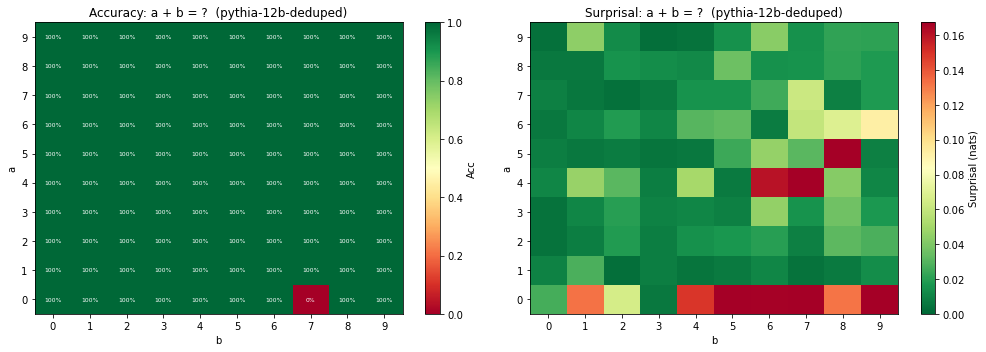

In [18]:
fig, (ax_acc, ax_surp) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy heatmap
piv_acc = df_single_eval.pivot(index="a", columns="b", values="correct")
im = ax_acc.imshow(piv_acc.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto", origin="lower")
ax_acc.set_xticks(range(10)); ax_acc.set_yticks(range(10))
ax_acc.set_xticklabels(range(10)); ax_acc.set_yticklabels(range(10))
ax_acc.set_xlabel("b"); ax_acc.set_ylabel("a")
ax_acc.set_title(f"Accuracy: a + b = ?  ({MODEL_NAME.split('/')[-1]})")
plt.colorbar(im, ax=ax_acc, label="Acc")
for i in range(10):
    for j in range(10):
        v = piv_acc.values[i, j]
        ax_acc.text(j, i, f"{v:.0%}", ha="center", va="center",
                    fontsize=6, color="black" if 0.2 < v < 0.85 else "white")

# Surprisal heatmap
piv_surp = df_single_eval.pivot(index="a", columns="b", values="surprisal")
vmax = df_single_eval["surprisal"].quantile(0.95)
im2 = ax_surp.imshow(piv_surp.values, cmap="RdYlGn_r", vmin=0, vmax=vmax, aspect="auto", origin="lower")
ax_surp.set_xticks(range(10)); ax_surp.set_yticks(range(10))
ax_surp.set_xticklabels(range(10)); ax_surp.set_yticklabels(range(10))
ax_surp.set_xlabel("b"); ax_surp.set_ylabel("a")
ax_surp.set_title(f"Surprisal: a + b = ?  ({MODEL_NAME.split('/')[-1]})")
plt.colorbar(im2, ax=ax_surp, label="Surprisal (nats)")

plt.tight_layout()
plt.savefig("single_digit_addition_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

### Identify 20 Lowest and 20 Highest Scoring Addition Problems

In [17]:
# Sort by accuracy (ascending), then surprisal (descending) as tiebreak
df_ranked = df_single_eval.sort_values(
    ["correct", "surprisal"], ascending=[True, False]
).reset_index(drop=True)

low_20 = df_ranked.head(20)
high_20 = df_ranked.tail(20).sort_values("surprisal")

display_cols = [
    "prompt",
    "target",
    "has_carry",
    "correct",
    "surprisal",
    "avg_target_logprob",
    "prediction",
    "freq_a",
    "freq_b",
]

print("=" * 70)
print("20 LOWEST SCORING (hardest) addition problems")
print("=" * 70)
print(low_20[display_cols].to_string(index=False))

print()
print("=" * 70)
print("20 HIGHEST SCORING (easiest) addition problems")
print("=" * 70)
print(high_20[display_cols].to_string(index=False))

# Store as (a, b) pairs and score lookups
low_pairs = list(zip(low_20["a"], low_20["b"]))
high_pairs = list(zip(high_20["a"], high_20["b"]))

score_logprob = {(r.a, r.b): r.avg_target_logprob for r in df_single_eval.itertuples()}
score_surprisal = {(r.a, r.b): r.surprisal for r in df_single_eval.itertuples()}
score_correct = {(r.a, r.b): r.correct for r in df_single_eval.itertuples()}

print(f"\nLow pairs  : {low_pairs}")
print(f"High pairs : {high_pairs}")

20 LOWEST SCORING (hardest) addition problems
 prompt target  has_carry  correct  surprisal  avg_target_logprob prediction  freq_a  freq_b
0 + 7 =      7          0    False   2.916016           -2.916016          8   11138    4303
5 + 8 =     13          1     True   0.535156           -0.535156         13    8265    4207
0 + 5 =      5          0     True   0.356445           -0.356445          5   11138    8265
0 + 9 =      9          0     True   0.265137           -0.265137          9   11138    3218
4 + 7 =     11          1     True   0.188232           -0.188232         11   11069    4303
0 + 6 =      6          0     True   0.166260           -0.166260          6   11138    4863
4 + 6 =     10          1     True   0.160400           -0.160400         10   11069    4863
0 + 4 =      4          0     True   0.148560           -0.148560          4   11138   11069
0 + 1 =      1          0     True   0.132446           -0.132446          1   11138   31497
0 + 8 =      8          

In [18]:
# ── Sanity-check: low/high sets must be disjoint ─────────────────────────────
low_set = set(low_pairs)
high_set = set(high_pairs)
overlap = low_set & high_set

assert not overlap, f"Overlap between low/high sets: {overlap}"
print(f"low_20  : {len(low_set)} unique pairs")
print(f"high_20 : {len(high_set)} unique pairs")
print(f"Overlap : {len(overlap)}  OK" if not overlap else f"Overlap : {overlap}  NOT OK")

print("\nCarry counts in low_20:")
print(low_20["has_carry"].value_counts().sort_index())
print("\nCarry counts in high_20:")
print(high_20["has_carry"].value_counts().sort_index())

print("\nMean surprisal by set:")
print(f"  low_20  : {low_20['surprisal'].mean():.3f}")
print(f"  high_20 : {high_20['surprisal'].mean():.3f}")

low_20  : 20 unique pairs
high_20 : 20 unique pairs
Overlap : 0  OK

Carry counts in low_20:
0    11
1     9
Name: has_carry, dtype: int64

Carry counts in high_20:
0    18
1     2
Name: has_carry, dtype: int64

Mean surprisal by set:
  low_20  : 0.279
  high_20 : 0.005


In [19]:
# ── Frequency comparison: are low-scoring problems also rarer in pretraining? ──
print("Frequency analysis (pretraining corpus):")
print()
print(f"  Low-20  avg freq_a : {low_20['freq_a'].mean():.1f}")
print(f"  High-20 avg freq_a : {high_20['freq_a'].mean():.1f}")
print(f"  Low-20  avg freq_b : {low_20['freq_b'].mean():.1f}")
print(f"  High-20 avg freq_b : {high_20['freq_b'].mean():.1f}")
print()

from scipy.stats import pearsonr, spearmanr
r_surp_fa, p_surp_fa = spearmanr(df_single_eval["surprisal"], df_single_eval["freq_a"])
r_surp_fb, p_surp_fb = spearmanr(df_single_eval["surprisal"], df_single_eval["freq_b"])
print(f"  Spearman corr(surprisal, freq_a): ρ={r_surp_fa:.3f}, p={p_surp_fa:.3e}")
print(f"  Spearman corr(surprisal, freq_b): ρ={r_surp_fb:.3f}, p={p_surp_fb:.3e}")

Frequency analysis (pretraining corpus):

  Low-20  avg freq_a : 9377.4
  High-20 avg freq_a : 13998.5
  Low-20  avg freq_b : 10451.6
  High-20 avg freq_b : 15592.3

  Spearman corr(surprisal, freq_a): ρ=-0.015, p=8.835e-01
  Spearman corr(surprisal, freq_b): ρ=-0.370, p=1.503e-04


## Multi-Digit Analysis Using Plain Addition Sub-step Scores

The multi-digit analysis below uses the single-digit `a + b = c` scores as sub-step scores for both the ones and tens columns. Since those sub-step scores no longer encode an incoming carry, we keep `carry_to_tens` as an explicit feature/control in the 2-digit analysis, but we do not balance the low/high single-digit pools or the 2-digit samples by carry status. Controlled-category labels are written in `tens-ones` order, using `easy`/`hard` rather than `high`/`low`.

In [20]:
def construct_controlled_2digit(low_pairs, high_pairs, score_surprisal, score_logprob):
    """
    Construct 2-digit addition problems whose ones/tens sub-steps come from the
    low/high single-digit pools. Composite surprisal is the sum of the ones and
    tens surprisals, using plain (a, b) scores for both columns regardless of
    carry_to_tens.
    """
    problems = []
    categories = [
        ("hard-hard", low_pairs, low_pairs),
        ("easy-easy", high_pairs, high_pairs),
        ("easy-hard", low_pairs, high_pairs),
        ("hard-easy", high_pairs, low_pairs),
    ]

    for cat, ones_pool, tens_pool in categories:
        for ones_a, ones_b in ones_pool:
            carry_to_tens = int((ones_a + ones_b) >= 10)
            for tens_a, tens_b in tens_pool:
                A = tens_a * 10 + ones_a
                B = tens_b * 10 + ones_b
                C = A + B

                s_ones = score_surprisal.get((ones_a, ones_b), float("nan"))
                s_tens = score_surprisal.get((tens_a, tens_b), float("nan"))
                lp_ones = score_logprob.get((ones_a, ones_b), float("nan"))
                lp_tens = score_logprob.get((tens_a, tens_b), float("nan"))

                problems.append({
                    "category": cat,
                    "A": A,
                    "B": B,
                    "C": C,
                    "prompt": f"{A} + {B} =",
                    "target": str(C),
                    "ones_a": ones_a,
                    "ones_b": ones_b,
                    "tens_a": tens_a,
                    "tens_b": tens_b,
                    "ones_has_carry": int((ones_a + ones_b) >= 10),
                    "tens_has_carry": int((tens_a + tens_b) >= 10),
                    "carry_to_tens": carry_to_tens,
                    "n_result_digits": len(str(C)),
                    "surp_ones": s_ones,
                    "surp_tens": s_tens,
                    "lp_ones": lp_ones,
                    "lp_tens": lp_tens,
                    "comp_surp_sum": s_ones + s_tens,
                    "comp_surp_max": max(s_ones, s_tens),
                    "comp_lp_sum": lp_ones + lp_tens,
                    "comp_lp_min": min(lp_ones, lp_tens),
                    "freq_pair_ones": freq_ab.get((ones_a, ones_b), 0),
                    "freq_pair_tens": freq_ab.get((tens_a, tens_b), 0),
                })

    df = pd.DataFrame(problems).drop_duplicates(subset=["category", "A", "B"]).reset_index(drop=True)
    df["freq_pair_sum"] = df["freq_pair_ones"] + df["freq_pair_tens"]
    return df


df_ctrl = construct_controlled_2digit(low_pairs, high_pairs, score_surprisal, score_logprob)
print(f"Controlled dataset: {len(df_ctrl)} 2-digit problems")
print(df_ctrl.groupby("category").size())
print() 
print(df_ctrl.groupby(["category", "carry_to_tens"]).size().unstack(fill_value=0))

Controlled dataset: 1600 2-digit problems
category
easy-easy    400
easy-hard    400
hard-easy    400
hard-hard    400
dtype: int64

carry_to_tens    0    1
category               
easy-easy      360   40
easy-hard      220  180
hard-easy      360   40
hard-hard      220  180


In [21]:
# ── All 2-digit addition problems with summed composite surprisal ────────────
def gen_all_2digit_problems(score_surprisal, score_logprob):
    rows = []
    for A in range(10, 100):
        for B in range(10, 100):
            C = A + B
            ones_a, ones_b = A % 10, B % 10
            tens_a, tens_b = A // 10, B // 10
            carry_to_tens = int((ones_a + ones_b) >= 10)

            s_ones = score_surprisal.get((ones_a, ones_b), float("nan"))
            s_tens = score_surprisal.get((tens_a, tens_b), float("nan"))
            lp_ones = score_logprob.get((ones_a, ones_b), float("nan"))
            lp_tens = score_logprob.get((tens_a, tens_b), float("nan"))

            rows.append({
                "A": A,
                "B": B,
                "C": C,
                "prompt": f"{A} + {B} =",
                "target": str(C),
                "ones_a": ones_a,
                "ones_b": ones_b,
                "tens_a": tens_a,
                "tens_b": tens_b,
                "ones_has_carry": int((ones_a + ones_b) >= 10),
                "tens_has_carry": int((tens_a + tens_b) >= 10),
                "carry_to_tens": carry_to_tens,
                "n_result_digits": len(str(C)),
                "surp_ones": s_ones,
                "surp_tens": s_tens,
                "lp_ones": lp_ones,
                "lp_tens": lp_tens,
                "comp_surp_sum": s_ones + s_tens,
                "comp_surp_max": max(s_ones, s_tens),
                "comp_lp_sum": lp_ones + lp_tens,
                "comp_lp_min": min(lp_ones, lp_tens),
                "freq_pair_ones": freq_ab.get((ones_a, ones_b), 0),
                "freq_pair_tens": freq_ab.get((tens_a, tens_b), 0),
            })
    df = pd.DataFrame(rows)
    df["freq_pair_sum"] = df["freq_pair_ones"] + df["freq_pair_tens"]
    return df


df_all2 = gen_all_2digit_problems(score_surprisal, score_logprob)
print(f"Full 2-digit dataset: {len(df_all2)} problems")

quartile_labels = ["Q1_easy", "Q2", "Q3", "Q4_hard"]
df_all2["score_quartile"] = pd.qcut(
    df_all2["comp_surp_sum"].rank(method="first"),
    4,
    labels=quartile_labels,
)

df_all2_sample = (
    df_all2.groupby("score_quartile", group_keys=False)
           .apply(lambda x: x.sample(min(10000, len(x)), random_state=42))
           .reset_index(drop=True)
)
print(f"Stratified sample: {len(df_all2_sample)}")
print(df_all2_sample["score_quartile"].value_counts().sort_index())

Full 2-digit dataset: 8100 problems
Stratified sample: 8100
Q1_easy    2025
Q2         2025
Q3         2025
Q4_hard    2025
Name: score_quartile, dtype: int64


### Evaluate Multi-Digit Problems

In [22]:
# ── Evaluate controlled (low/high) dataset ───────────────────────────────────
_prefix_2digit = build_kshot_prefix(K_SHOT, problem_type="2digit")
df_ctrl_kshot = apply_kshot_prefix(df_ctrl, _prefix_2digit)

df_ctrl_eval = eval_logprob(
    model,
    tokenizer,
    df_ctrl_kshot,
    batch_size=BATCH_SIZE_LOGPROB,
    prompt_col="eval_prompt",
)
df_ctrl_eval = eval_accuracy(
    model,
    tokenizer,
    df_ctrl_eval,
    batch_size=BATCH_SIZE_ACCURACY,
    prompt_col="eval_prompt",
)
df_ctrl_eval["model"] = MODEL_NAME
df_ctrl_eval["k_shot"] = K_SHOT

print(df_ctrl_eval.groupby("category")[["correct", "surprisal", "comp_surp_sum"]].mean().round(3))

logprob:   0%|          | 0/25 [00:00<?, ?it/s]

accuracy:   0%|          | 0/50 [00:00<?, ?it/s]

           correct  surprisal  comp_surp_sum
category                                    
easy-easy    0.988      0.095          0.010
easy-hard    0.968      0.154          0.284
hard-easy    0.805      0.562          0.284
hard-hard    0.765      0.625          0.558


In [23]:
# ── Evaluate stratified 2-digit sample ───────────────────────────────────────
df_s2_kshot = apply_kshot_prefix(df_all2_sample, _prefix_2digit)

df_s2_eval = eval_logprob(
    model,
    tokenizer,
    df_s2_kshot,
    batch_size=BATCH_SIZE_LOGPROB,
    prompt_col="eval_prompt",
)
df_s2_eval = eval_accuracy(
    model,
    tokenizer,
    df_s2_eval,
    batch_size=BATCH_SIZE_ACCURACY,
    prompt_col="eval_prompt",
)
df_s2_eval["model"] = MODEL_NAME
df_s2_eval["k_shot"] = K_SHOT

print(f"K_SHOT={K_SHOT}  |  Overall 2-digit accuracy: {df_s2_eval['correct'].mean():.3f}")
print(df_s2_eval.groupby("score_quartile")[["correct", "surprisal", "comp_surp_sum"]].mean().round(3))

logprob:   0%|          | 0/127 [00:00<?, ?it/s]

accuracy:   0%|          | 0/254 [00:00<?, ?it/s]

K_SHOT=4  |  Overall 2-digit accuracy: 0.830
                correct  surprisal  comp_surp_sum
score_quartile                                   
Q1_easy           0.910      0.302          0.017
Q2                0.852      0.485          0.029
Q3                0.802      0.569          0.050
Q4_hard           0.756      0.664          0.294


### Composite Surprisal Sum Analysis

In [24]:
from scipy.stats import pearsonr, spearmanr

print("=== Correlation: composite sub-step surprisal -> multi-digit performance ===\n")
for col in ["comp_surp_sum", "comp_surp_max"]:
    r, p = spearmanr(df_s2_eval[col], df_s2_eval["surprisal"])
    print(f"{col:15s} vs surprisal : rho={r:+.3f}, p={p:.3e}")
print()
for col in ["comp_surp_sum", "comp_surp_max"]:
    r, p = spearmanr(df_s2_eval[col], df_s2_eval["correct"].astype(float))
    print(f"{col:15s} vs accuracy  : rho={r:+.3f}, p={p:.3e}")

=== Correlation: composite sub-step surprisal -> multi-digit performance ===

comp_surp_sum   vs surprisal : rho=+0.197, p=7.846e-72
comp_surp_max   vs surprisal : rho=+0.179, p=1.568e-59

comp_surp_sum   vs accuracy  : rho=-0.161, p=2.152e-48
comp_surp_max   vs accuracy  : rho=-0.149, p=2.380e-41


In [25]:
from sklearn.linear_model import LinearRegression, LogisticRegression

X = df_s2_eval[["comp_surp_sum", "carry_to_tens", "freq_pair_sum", "n_result_digits"]].values
y_surp = df_s2_eval["surprisal"].values
y_acc = df_s2_eval["correct"].astype(int).values

lin = LinearRegression().fit(X, y_surp)

print("=== Simple regressions with controls ===")
print(f"Linear R^2   (surprisal): {lin.score(X, y_surp):.3f}")
print()
print("Feature order:")
print("  comp_surp_sum, carry_to_tens, freq_pair_sum, n_result_digits")
print("Linear coefficients:")
print(pd.Series(lin.coef_, index=["comp_surp_sum", "carry_to_tens", "freq_pair_sum", "n_result_digits"]).round(4))

if len(np.unique(y_acc)) < 2:
    print("\nSkipped logistic regression: only one accuracy class present in df_s2_eval.")
else:
    log = LogisticRegression(max_iter=1000).fit(X, y_acc)
    print(f"\nLogistic acc (accuracy) : {log.score(X, y_acc):.3f}")

=== Simple regressions with controls ===
Linear R^2   (surprisal): 0.127

Feature order:
  comp_surp_sum, carry_to_tens, freq_pair_sum, n_result_digits
Linear coefficients:
comp_surp_sum      0.0513
carry_to_tens      0.0435
freq_pair_sum     -0.0000
n_result_digits    0.5691
dtype: float64

Logistic acc (accuracy) : 0.830


In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

features = ["comp_surp_sum", "carry_to_tens", "freq_pair_sum", "n_result_digits"]

X = df_s2_eval[features].copy()
X_sm = sm.add_constant(X)  # adds intercept

y_surp = df_s2_eval["surprisal"].values
y_acc = df_s2_eval["correct"].astype(int).values

print("=== Statsmodels regressions with controls ===")

# OLS for surprisal
ols = sm.OLS(y_surp, X_sm).fit()
print("\n=== OLS: surprisal ===")
print(ols.summary())

# If you want just coefficients/p-values:
print("\nOLS coefficients:")
print(ols.params.round(4))
print("\nOLS p-values:")
print(ols.pvalues.round(4))

# Logistic regression for accuracy
if len(np.unique(y_acc)) < 2:
    print("\nSkipped logistic regression: only one accuracy class present in df_s2_eval.")
else:
    logit = sm.Logit(y_acc, X_sm).fit(disp=False)
    print("\n=== Logistic: correct ===")
    print(logit.summary())

    print("\nLogit coefficients:")
    print(logit.params.round(4))
    print("\nLogit p-values:")
    print(logit.pvalues.round(4))

    # Optional: odds ratios
    print("\nOdds ratios:")
    print(np.exp(logit.params).round(4))


=== Statsmodels regressions with controls ===

=== OLS: surprisal ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     293.4
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          5.76e-236
Time:                        16:54:13   Log-Likelihood:                -9153.6
No. Observations:                8100   AIC:                         1.832e+04
Df Residuals:                    8095   BIC:                         1.835e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [27]:
from scipy.stats import ttest_ind

summary = df_ctrl_eval.groupby("category").agg(
    n=("correct", "count"),
    accuracy=("correct", "mean"),
    mean_surprisal=("surprisal", "mean"),
    mean_comp_surp_sum=("comp_surp_sum", "mean"),
    carry_rate=("carry_to_tens", "mean"),
).round(3)
print(summary)

print("\n=== Pairwise t-tests on surprisal ===")
cats = list(summary.index)
for i, c1 in enumerate(cats):
    for c2 in cats[i+1:]:
        s1 = df_ctrl_eval[df_ctrl_eval.category == c1]["surprisal"]
        s2 = df_ctrl_eval[df_ctrl_eval.category == c2]["surprisal"]
        t, p = ttest_ind(s1, s2, equal_var=False)
        print(f"{c1:10s} vs {c2:10s}: t={t:+.2f}, p={p:.3e}")

             n  accuracy  mean_surprisal  mean_comp_surp_sum  carry_rate
category                                                                
easy-easy  400     0.988           0.095               0.010        0.10
easy-hard  400     0.968           0.154               0.284        0.45
hard-easy  400     0.805           0.562               0.284        0.10
hard-hard  400     0.765           0.625               0.558        0.45

=== Pairwise t-tests on surprisal ===
easy-easy  vs easy-hard : t=-2.96, p=3.189e-03
easy-easy  vs hard-easy : t=-10.99, p=6.230e-25
easy-easy  vs hard-hard : t=-11.66, p=1.890e-27
easy-hard  vs hard-easy : t=-8.95, p=5.451e-18
easy-hard  vs hard-hard : t=-9.74, p=9.717e-21
hard-easy  vs hard-hard : t=-1.04, p=2.980e-01


### Visualizations

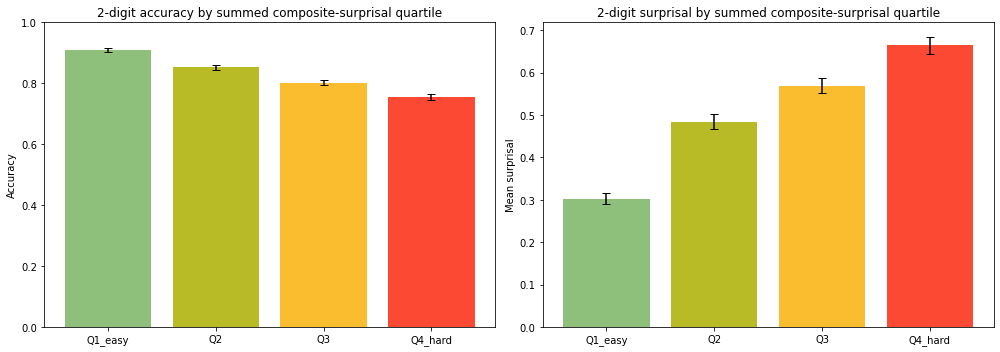

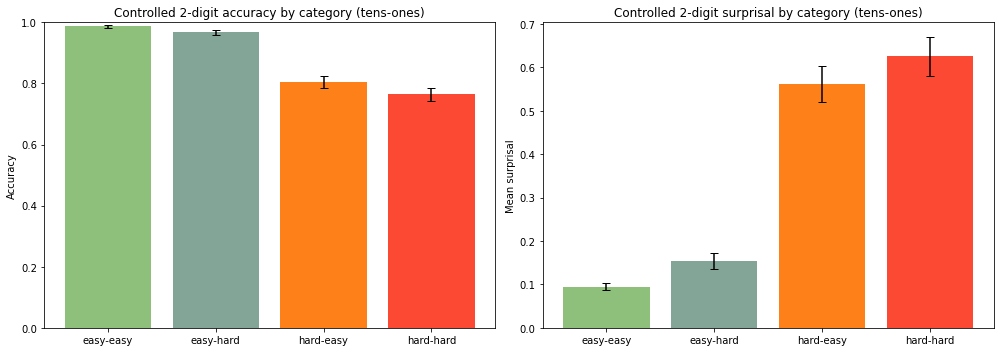

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quartile_order = ["Q1_easy", "Q2", "Q3", "Q4_hard"]
q_acc = df_s2_eval.groupby("score_quartile")["correct"].mean().reindex(quartile_order)
q_acc_se = df_s2_eval.groupby("score_quartile")["correct"].sem().reindex(quartile_order)
q_surp = df_s2_eval.groupby("score_quartile")["surprisal"].mean().reindex(quartile_order)
q_surp_se = df_s2_eval.groupby("score_quartile")["surprisal"].sem().reindex(quartile_order)

axes[0].bar(q_acc.index, q_acc.values, yerr=q_acc_se.values, capsize=4,
            color=["#8ec07c", "#b8bb26", "#fabd2f", "#fb4934"])
axes[0].set_title("2-digit accuracy by summed composite-surprisal quartile")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(q_surp.index, q_surp.values, yerr=q_surp_se.values, capsize=4,
            color=["#8ec07c", "#b8bb26", "#fabd2f", "#fb4934"])
axes[1].set_title("2-digit surprisal by summed composite-surprisal quartile")
axes[1].set_ylabel("Mean surprisal")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_order = ["easy-easy", "easy-hard", "hard-easy", "hard-hard"]
cat_acc = df_ctrl_eval.groupby("category")["correct"].mean().reindex(cat_order)
cat_acc_se = df_ctrl_eval.groupby("category")["correct"].sem().reindex(cat_order)
cat_surp = df_ctrl_eval.groupby("category")["surprisal"].mean().reindex(cat_order)
cat_surp_se = df_ctrl_eval.groupby("category")["surprisal"].sem().reindex(cat_order)
axes[0].bar(cat_acc.index, cat_acc.values, yerr=cat_acc_se.values, capsize=4,
            color=["#8ec07c", "#83a598", "#fe8019", "#fb4934"])
axes[0].set_title("Controlled 2-digit accuracy by category (tens-ones)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(cat_surp.index, cat_surp.values, yerr=cat_surp_se.values, capsize=4,
            color=["#8ec07c", "#83a598", "#fe8019", "#fb4934"])
axes[1].set_title("Controlled 2-digit surprisal by category (tens-ones)")
axes[1].set_ylabel("Mean surprisal")
plt.tight_layout()
plt.show()

### Carry-Stratified Tens-vs-Ones Comparison

To control for carry effects, we can re-plot the controlled categories **within each `carry_to_tens` regime**. This keeps the carry condition fixed and lets us compare whether `hard-easy` (hard tens, easy ones) is worse than `easy-hard` (easy tens, hard ones) among problems with **no carry** and among problems with **carry** separately.

Carry-stratified controlled summary:


n  accuracy  accuracy_se  mean_surprisal  \
carry_to_tens category                                                
0             easy-easy  360     0.989        0.006           0.088   
              easy-hard  220     0.991        0.006           0.097   
              hard-easy  360     0.800        0.021           0.576   
              hard-hard  220     0.773        0.028           0.577   
1             easy-easy   40     0.975        0.025           0.153   
              easy-hard  180     0.939        0.018           0.225   
              hard-easy   40     0.850        0.057           0.431   
              hard-hard  180     0.756        0.032           0.684   

                         surprisal_se  
carry_to_tens category                 
0             easy-easy         0.008  
              easy-hard         0.012  
              hard-easy         0.045  
              hard-hard         0.059  
1             easy-easy         0.039  
              easy-hard         0.037  
              hard-easy         0.082  
              hard-hard         0.069

When this surprisal delta is positive, hard tens are hurting more than hard ones within the same carry regime.


,accuracy_delta_hard_easy_minus_easy_hard,surprisal_delta_hard_easy_minus_easy_hard
carry_to_tens,,
No carry to tens,-0.191,0.479
Carry to tens,-0.089,0.206


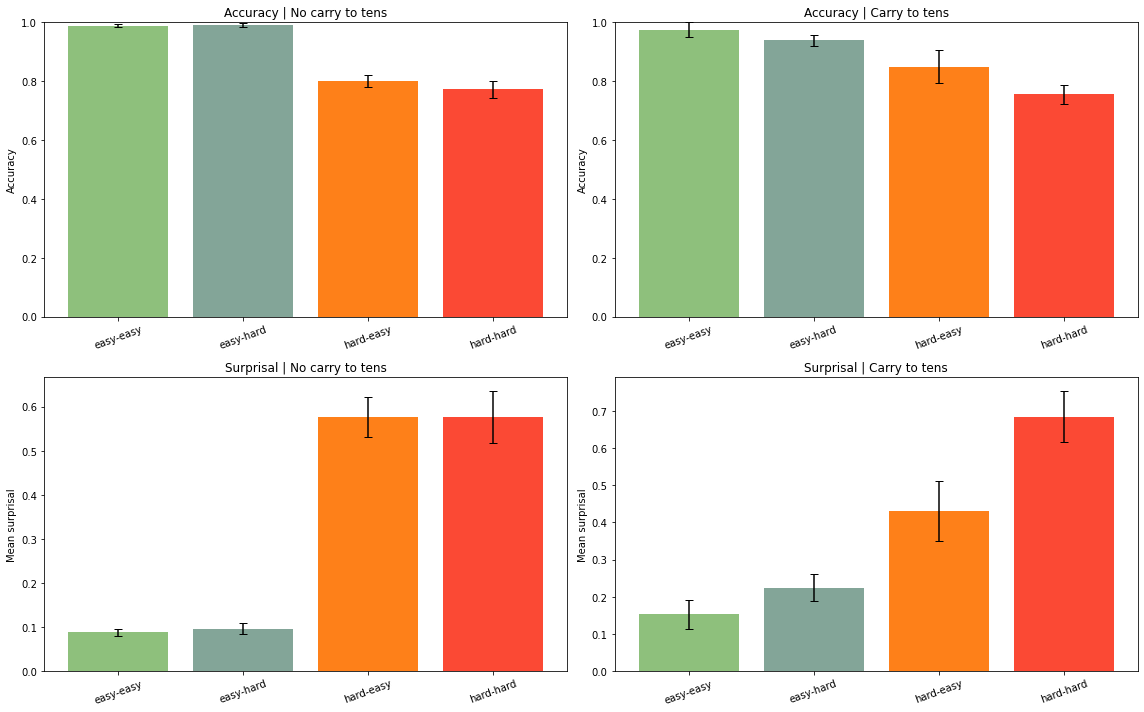

In [29]:
cat_order = ["easy-easy", "easy-hard", "hard-easy", "hard-hard"]
carry_order = [0, 1]
carry_labels = {0: "No carry to tens", 1: "Carry to tens"}
bar_colors = ["#8ec07c", "#83a598", "#fe8019", "#fb4934"]

carry_summary = (
    df_ctrl_eval.groupby(["carry_to_tens", "category"])
              .agg(
                  n=("correct", "size"),
                  accuracy=("correct", "mean"),
                  accuracy_se=("correct", "sem"),
                  mean_surprisal=("surprisal", "mean"),
                  surprisal_se=("surprisal", "sem"),
              )
              .round(3)
)
print("Carry-stratified controlled summary:")
display(carry_summary)

focus = carry_summary.reset_index()
focus = focus[focus["category"].isin(["easy-hard", "hard-easy"])]
focus_piv = focus.pivot(index="carry_to_tens", columns="category").reindex(carry_order)
comparison = pd.DataFrame({
    "accuracy_delta_hard_easy_minus_easy_hard": focus_piv[("accuracy", "hard-easy")] - focus_piv[("accuracy", "easy-hard")],
    "surprisal_delta_hard_easy_minus_easy_hard": focus_piv[("mean_surprisal", "hard-easy")] - focus_piv[("mean_surprisal", "easy-hard")],
}).rename(index=carry_labels).round(3)
print("When this surprisal delta is positive, hard tens are hurting more than hard ones within the same carry regime.")
display(comparison)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, carry_val in enumerate(carry_order):
    subset = df_ctrl_eval[df_ctrl_eval["carry_to_tens"] == carry_val]

    acc_mean = subset.groupby("category")["correct"].mean().reindex(cat_order)
    acc_se = subset.groupby("category")["correct"].sem().reindex(cat_order).fillna(0)
    axes[0, col_idx].bar(cat_order, acc_mean.values, yerr=acc_se.values, capsize=4, color=bar_colors)
    axes[0, col_idx].set_title(f"Accuracy | {carry_labels[carry_val]}")
    axes[0, col_idx].set_ylabel("Accuracy")
    axes[0, col_idx].set_ylim(0, 1)
    axes[0, col_idx].tick_params(axis="x", rotation=20)

    surp_mean = subset.groupby("category")["surprisal"].mean().reindex(cat_order)
    surp_se = subset.groupby("category")["surprisal"].sem().reindex(cat_order).fillna(0)
    axes[1, col_idx].bar(cat_order, surp_mean.values, yerr=surp_se.values, capsize=4, color=bar_colors)
    axes[1, col_idx].set_title(f"Surprisal | {carry_labels[carry_val]}")
    axes[1, col_idx].set_ylabel("Mean surprisal")
    axes[1, col_idx].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### Extreme Carry Regimes

We can also isolate the two cleanest carry settings: (1) **no carries at all**, where neither ones nor tens overflow, and (2) **carry in both ones and tens**, where the ones column carries into tens and the tens column carries into hundreds.

Extreme-carry controlled summary:


n  accuracy  accuracy_se  mean_surprisal  \
carry_regime category                                                
carry_both   easy-easy    4     1.000        0.000           0.097   
             easy-hard   18     0.778        0.101           0.474   
             hard-easy   18     0.778        0.101           0.620   
             hard-hard   81     0.605        0.055           0.895   
no_carries   easy-easy  324     0.994        0.004           0.067   
             easy-hard  198     0.990        0.007           0.091   
             hard-easy  198     0.949        0.016           0.186   
             hard-hard  121     0.992        0.008           0.112   

                        surprisal_se  
carry_regime category                 
carry_both   easy-easy         0.036  
             easy-hard         0.130  
             hard-easy         0.133  
             hard-hard         0.098  
no_carries   easy-easy         0.007  
             easy-hard         0.013  
             hard-easy         0.022  
             hard-hard         0.016

Positive surprisal delta means hard tens hurt more than hard ones in that regime.


,accuracy_delta_hard_easy_minus_easy_hard,surprisal_delta_hard_easy_minus_easy_hard
carry_regime,,
No carries at all,-0.041,0.095
Carry in ones and tens,0.000,0.146


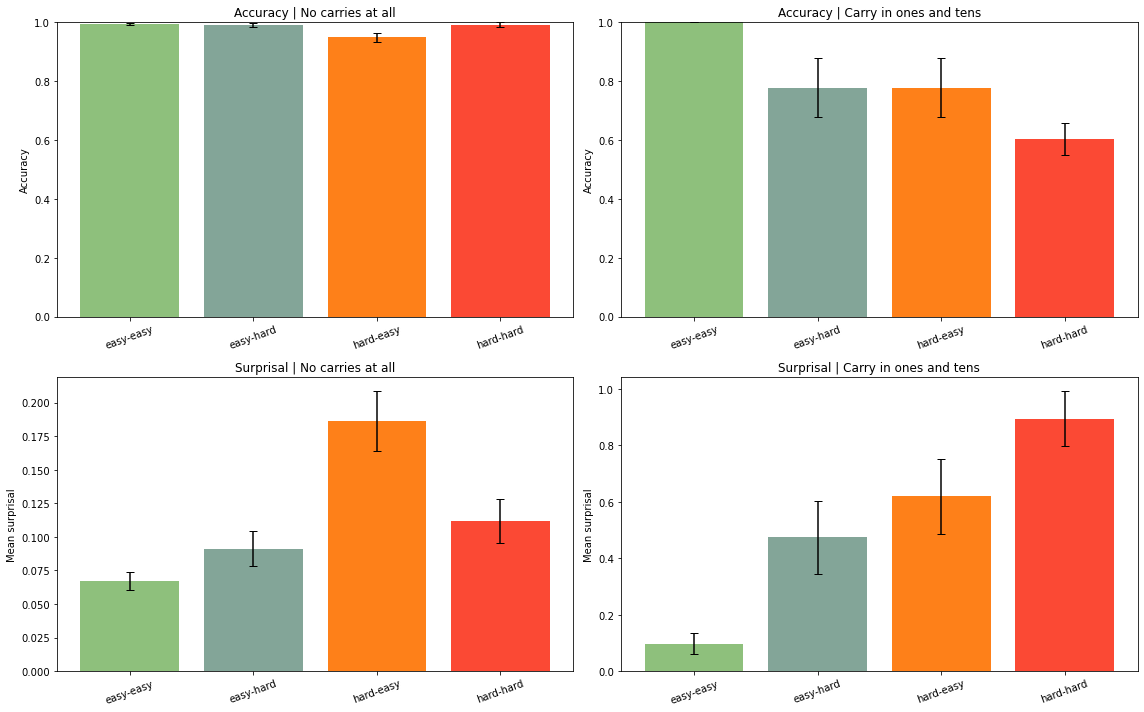

In [30]:
cat_order = ["easy-easy", "easy-hard", "hard-easy", "hard-hard"]
bar_colors = ["#8ec07c", "#83a598", "#fe8019", "#fb4934"]

df_ctrl_extreme = df_ctrl_eval.copy()
df_ctrl_extreme["carry_regime"] = np.select(
    [
        (df_ctrl_extreme["carry_to_tens"] == 0) & (df_ctrl_extreme["tens_has_carry"] == 0),
        (df_ctrl_extreme["carry_to_tens"] == 1) & (df_ctrl_extreme["tens_has_carry"] == 1),
    ],
    ["no_carries", "carry_both"],
    default="other",
)

extreme_order = ["no_carries", "carry_both"]
extreme_labels = {
    "no_carries": "No carries at all",
    "carry_both": "Carry in ones and tens",
}

extreme_summary = (
    df_ctrl_extreme[df_ctrl_extreme["carry_regime"].isin(extreme_order)]
        .groupby(["carry_regime", "category"])
        .agg(
            n=("correct", "size"),
            accuracy=("correct", "mean"),
            accuracy_se=("correct", "sem"),
            mean_surprisal=("surprisal", "mean"),
            surprisal_se=("surprisal", "sem"),
        )
        .round(3)
)
print("Extreme-carry controlled summary:")
display(extreme_summary)

focus = extreme_summary.reset_index()
focus = focus[focus["category"].isin(["easy-hard", "hard-easy"])]
focus_piv = focus.pivot(index="carry_regime", columns="category").reindex(extreme_order)
extreme_comparison = pd.DataFrame({
    "accuracy_delta_hard_easy_minus_easy_hard": focus_piv[("accuracy", "hard-easy")] - focus_piv[("accuracy", "easy-hard")],
    "surprisal_delta_hard_easy_minus_easy_hard": focus_piv[("mean_surprisal", "hard-easy")] - focus_piv[("mean_surprisal", "easy-hard")],
}).rename(index=extreme_labels).round(3)
print("Positive surprisal delta means hard tens hurt more than hard ones in that regime.")
display(extreme_comparison)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, regime in enumerate(extreme_order):
    subset = df_ctrl_extreme[df_ctrl_extreme["carry_regime"] == regime]

    acc_mean = subset.groupby("category")["correct"].mean().reindex(cat_order)
    acc_se = subset.groupby("category")["correct"].sem().reindex(cat_order).fillna(0)
    axes[0, col_idx].bar(cat_order, acc_mean.values, yerr=acc_se.values, capsize=4, color=bar_colors)
    axes[0, col_idx].set_title(f"Accuracy | {extreme_labels[regime]}")
    axes[0, col_idx].set_ylabel("Accuracy")
    axes[0, col_idx].set_ylim(0, 1)
    axes[0, col_idx].tick_params(axis="x", rotation=20)

    surp_mean = subset.groupby("category")["surprisal"].mean().reindex(cat_order)
    surp_se = subset.groupby("category")["surprisal"].sem().reindex(cat_order).fillna(0)
    axes[1, col_idx].bar(cat_order, surp_mean.values, yerr=surp_se.values, capsize=4, color=bar_colors)
    axes[1, col_idx].set_title(f"Surprisal | {extreme_labels[regime]}")
    axes[1, col_idx].set_ylabel("Mean surprisal")
    axes[1, col_idx].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### Prominent Result Numbers

Using the same definition as `metrics.ipynb`, we treat **powers of 2**, **powers of 10**, and **multiples of 10** as prominent numbers, and test whether problems whose correct result is prominent have different arithmetic **accuracy** or **surprisal**. This is computed once over the combined addition evaluations rather than split into single-digit vs 2-digit sections.

Combined addition evaluations by source:
two_digit_sample    8100
single_digit         100

=== All evaluated addition problems ===
                  n  accuracy  mean_surprisal  median_surprisal
non_prominent  7232     0.834           0.493             0.156
prominent       968     0.817           0.551             0.149
accuracy delta (prominent - non): -0.017 | z=-1.32, p=1.859e-01
surprisal delta (prominent - non): +0.059 | t=+1.99, p=4.643e-02

Prominent result values: All evaluated addition problems
 result_abs prominent_label  n  accuracy  mean_surprisal
          2             2^1  3     1.000           0.033
          4             2^2  5     1.000           0.039
          8             2^3  9     1.000           0.028
         10            10^1  9     1.000           0.038
         16             2^4  3     1.000           0.018
         20             x10  1     1.000           0.039
         30             x10 11     1.000           0.028
         32             2^5 13   

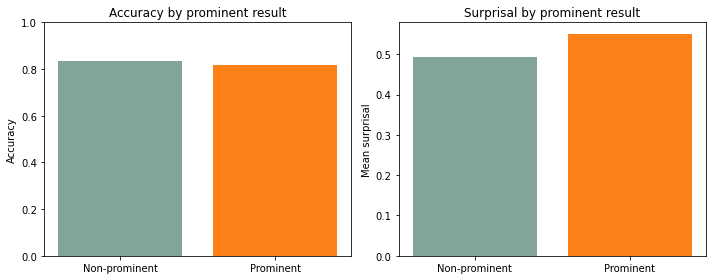

In [31]:
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

powers_of_2 = {2**i for i in range(1, 60)}
powers_of_10 = {10**i for i in range(1, 20)}
multiples_of_10 = {10 * i for i in range(1, 2000)}
prominent_results = powers_of_2 | powers_of_10 | multiples_of_10

def prominent_result_label(v):
    v = int(v)
    labels = []
    if v in powers_of_2:
        labels.append(f"2^{int(np.log2(v))}")
    if v in powers_of_10:
        labels.append(f"10^{int(np.log10(v))}")
    elif v != 0 and v % 10 == 0:
        labels.append("x10")
    return ", ".join(labels)

df_add_all = pd.concat([
    df_single_eval.assign(
        eval_source="single_digit",
        target_value=df_single_eval["target"].astype(int),
        left_operand=df_single_eval["a"].astype(int),
        right_operand=df_single_eval["b"].astype(int),
    ),
    df_s2_eval.assign(
        eval_source="two_digit_sample",
        target_value=df_s2_eval["C"].astype(int),
        left_operand=df_s2_eval["A"].astype(int),
        right_operand=df_s2_eval["B"].astype(int),
    ),
], ignore_index=True, sort=False)

def annotate_prominent_results(df, result_col):
    out = df.copy()
    out["result_value"] = out[result_col].astype(int)
    out["result_abs"] = out["result_value"].abs()
    out["result_digits"] = out["result_abs"].apply(lambda v: len(str(int(v))) if int(v) != 0 else 1)
    out["is_prominent_result"] = out["result_abs"].isin(prominent_results)
    out["prominent_label"] = out["result_abs"].apply(prominent_result_label)
    return out

df_add_all_prom = annotate_prominent_results(df_add_all, "target_value")

def summarize_prominence(df, dataset_name):
    summary = (
        df.groupby("is_prominent_result")
          .agg(
              n=("correct", "size"),
              accuracy=("correct", "mean"),
              mean_surprisal=("surprisal", "mean"),
              median_surprisal=("surprisal", "median"),
          )
          .reindex([False, True])
    )
    summary.index = ["non_prominent", "prominent"]
    print(f"=== {dataset_name} ===")
    print(summary.round(3))

    prominent = df[df["is_prominent_result"]]
    baseline = df[~df["is_prominent_result"]]
    z_acc, p_acc = proportions_ztest(
        [prominent["correct"].sum(), baseline["correct"].sum()],
        [len(prominent), len(baseline)],
    )
    t_surp, p_surp = ttest_ind(prominent["surprisal"], baseline["surprisal"], equal_var=False)
    print(f"accuracy delta (prominent - non): {prominent['correct'].mean() - baseline['correct'].mean():+.3f} | z={z_acc:+.2f}, p={p_acc:.3e}")
    print(f"surprisal delta (prominent - non): {prominent['surprisal'].mean() - baseline['surprisal'].mean():+.3f} | t={t_surp:+.2f}, p={p_surp:.3e}")
    print()

def prominent_result_table(df, dataset_name, max_rows=15):
    table = (
        df[df["is_prominent_result"]]
          .groupby(["result_abs", "prominent_label"])
          .agg(
              n=("correct", "size"),
              accuracy=("correct", "mean"),
              mean_surprisal=("surprisal", "mean"),
          )
          .reset_index()
          .sort_values(["result_abs", "prominent_label"])
    )
    print(f"Prominent result values: {dataset_name}")
    print(table.head(max_rows).round(3).to_string(index=False))
    print()

print("Combined addition evaluations by source:")
print(df_add_all_prom["eval_source"].value_counts().to_string())
print()

summarize_prominence(df_add_all_prom, "All evaluated addition problems")
prominent_result_table(df_add_all_prom, "All evaluated addition problems", max_rows=25)

plot_df = (
    df_add_all_prom.groupby("is_prominent_result")
                  .agg(accuracy=("correct", "mean"), mean_surprisal=("surprisal", "mean"))
                  .reindex([False, True])
)
labels = ["Non-prominent", "Prominent"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, plot_df["accuracy"].values, color=["#83a598", "#fe8019"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by prominent result")

axes[1].bar(labels, plot_df["mean_surprisal"].values, color=["#83a598", "#fe8019"])
axes[1].set_ylabel("Mean surprisal")
axes[1].set_title("Surprisal by prominent result")

plt.tight_layout()
plt.show()


### Prominent Operands

We can also ask whether arithmetic is easier when the **operands themselves** are prominent numbers. Here we use the same prominence definition as above and compare problems where **both operands are prominent**, **both are non-prominent**, or the pair is **mixed**, again over the combined addition evaluations.

=== All evaluated addition problems ===
                               n  accuracy  mean_surprisal  median_surprisal
operand_prominence_pattern                                                  
both_non_prominent          6133     0.822           0.535             0.182
mixed                       1914     0.859           0.408             0.092
both_prominent               153     0.902           0.230             0.042
accuracy delta (both prominent - both non): +0.080 | z=+2.57, p=1.027e-02
surprisal delta (both prominent - both non): -0.305 | t=-7.15, p=2.431e-11

Most surprising both-prominent operand problems: All evaluated addition problems
   prompt  left_operand  right_operand  correct  surprisal operand_prominence_pattern
40 + 70 =            40             70    False      3.209             both_prominent
30 + 50 =            30             50    False      2.908             both_prominent
50 + 90 =            50             90    False      2.262             both_prominent


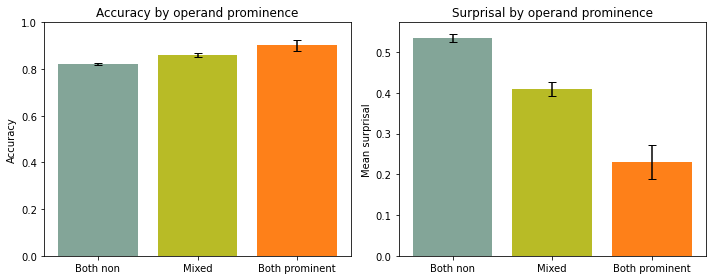

In [32]:
def annotate_prominent_operands(df, left_col, right_col):
    out = df.copy()
    out["left_operand"] = out[left_col].astype(int)
    out["right_operand"] = out[right_col].astype(int)
    out["left_abs"] = out["left_operand"].abs()
    out["right_abs"] = out["right_operand"].abs()
    out["left_digits"] = out["left_abs"].apply(lambda v: len(str(int(v))) if int(v) != 0 else 1)
    out["right_digits"] = out["right_abs"].apply(lambda v: len(str(int(v))) if int(v) != 0 else 1)
    out["operand_digit_pair"] = out.apply(lambda r: f"{r['left_digits']}d+{r['right_digits']}d", axis=1)
    out["left_prominent"] = out["left_abs"].isin(prominent_results)
    out["right_prominent"] = out["right_abs"].isin(prominent_results)
    out["both_operands_prominent"] = out["left_prominent"] & out["right_prominent"]
    out["both_operands_non_prominent"] = (~out["left_prominent"]) & (~out["right_prominent"])
    out["operand_prominence_pattern"] = np.select(
        [
            out["both_operands_non_prominent"],
            out["both_operands_prominent"],
        ],
        ["both_non_prominent", "both_prominent"],
        default="mixed",
    )
    return out

df_add_all_ops = annotate_prominent_operands(df_add_all_prom, "left_operand", "right_operand")

def summarize_operand_prominence(df, dataset_name):
    order = ["both_non_prominent", "mixed", "both_prominent"]
    summary = (
        df.groupby("operand_prominence_pattern")
          .agg(
              n=("correct", "size"),
              accuracy=("correct", "mean"),
              mean_surprisal=("surprisal", "mean"),
              median_surprisal=("surprisal", "median"),
          )
          .reindex(order)
    )
    print(f"=== {dataset_name} ===")
    print(summary.round(3))

    prom = df[df["operand_prominence_pattern"] == "both_prominent"]
    non = df[df["operand_prominence_pattern"] == "both_non_prominent"]
    z_acc, p_acc = proportions_ztest(
        [prom["correct"].sum(), non["correct"].sum()],
        [len(prom), len(non)],
    )
    t_surp, p_surp = ttest_ind(prom["surprisal"], non["surprisal"], equal_var=False)
    print(f"accuracy delta (both prominent - both non): {prom['correct'].mean() - non['correct'].mean():+.3f} | z={z_acc:+.2f}, p={p_acc:.3e}")
    print(f"surprisal delta (both prominent - both non): {prom['surprisal'].mean() - non['surprisal'].mean():+.3f} | t={t_surp:+.2f}, p={p_surp:.3e}")
    print()

def prominent_operand_examples(df, dataset_name, max_rows=15):
    cols = [c for c in ["prompt", "left_operand", "right_operand", "correct", "surprisal", "operand_prominence_pattern"] if c in df.columns]
    print(f"Most surprising both-prominent operand problems: {dataset_name}")
    print(
        df[df["operand_prominence_pattern"] == "both_prominent"]
          .sort_values("surprisal", ascending=False)[cols]
          .head(max_rows)
          .round(3)
          .to_string(index=False)
    )
    print()

summarize_operand_prominence(df_add_all_ops, "All evaluated addition problems")
prominent_operand_examples(df_add_all_ops, "All evaluated addition problems", max_rows=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
order = ["both_non_prominent", "mixed", "both_prominent"]
labels = ["Both non", "Mixed", "Both prominent"]
plot_df = (
    df_add_all_ops.groupby("operand_prominence_pattern")
                  .agg(
                      accuracy=("correct", "mean"),
                      accuracy_se=("correct", "sem"),
                      mean_surprisal=("surprisal", "mean"),
                      surprisal_se=("surprisal", "sem"),
                  )
                  .reindex(order)
)
axes[0].bar(labels, plot_df["accuracy"].values, yerr=plot_df["accuracy_se"].fillna(0).values, capsize=4,
            color=["#83a598", "#b8bb26", "#fe8019"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by operand prominence")

axes[1].bar(labels, plot_df["mean_surprisal"].values, yerr=plot_df["surprisal_se"].fillna(0).values, capsize=4,
            color=["#83a598", "#b8bb26", "#fe8019"])
axes[1].set_ylabel("Mean surprisal")
axes[1].set_title("Surprisal by operand prominence")

plt.tight_layout()
plt.show()
